In [17]:
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, callbacks,utils
from imblearn.over_sampling import ADASYN,SMOTE
from collections import Counter
from keras.optimizers import Adam

from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [18]:
df=pd.read_csv("augmented_dataset_taiwan_3000.csv")

df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [19]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['status']
X=df[features]
y=df[status]  


In [20]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [22]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [23]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
print(X_scaled.shape)

(105531, 8)


In [ ]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    
    
    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Second Dense layer
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'

    ]
)

In [27]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_rf_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [28]:
model.fit(
X_scaled, y_train,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks

)#training nn

Epoch 1/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7875 - loss: 0.6809 - val_accuracy: 0.9054 - val_loss: 0.3126 - learning_rate: 5.0000e-04
Epoch 2/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8914 - loss: 0.3280 - val_accuracy: 0.9085 - val_loss: 0.2343 - learning_rate: 5.0000e-04
Epoch 3/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8963 - loss: 0.2843 - val_accuracy: 0.9108 - val_loss: 0.2209 - learning_rate: 5.0000e-04
Epoch 4/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8981 - loss: 0.2687 - val_accuracy: 0.9100 - val_loss: 0.2186 - learning_rate: 5.0000e-04
Epoch 5/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9004 - loss: 0.2605 - val_accuracy: 0.9124 - val_loss: 0.2140 - learning_rate: 5.0000e-04
Epoch 6/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9008 - loss: 0.2519 - val_accuracy: 0.9131 - val_loss: 0.2118 - learning_rate: 5.0000e-04
Epoch 7/100
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

In [29]:
# 1. Generate soft pseudo-labels from your trained Normal NN teacher
nn_predictions = model.predict(X_scaled)
y_pseudo_train = np.argmax(nn_predictions, axis=1)

# 2. Train the Random Forest on the tabular data using the NN's pseudo-labels
rf_distilled = RandomForestClassifier(n_estimators=100, random_state=20, class_weight='balanced_subsample', n_jobs=-1)
rf_distilled.fit(X_scaled, y_pseudo_train)

# 3. Scale and prepare your raw test subset
X_test_scaled = scaler.transform(X_test)

# 4. Predict using the distilled Random Forest model
y_pred_rf = rf_distilled.predict(X_test_scaled)

print("--- Distilled Random Forest Performance (Normal NN Teacher) ---")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

3298/3298 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
--- Distilled Random Forest Performance (Normal NN Teacher) ---
                                precision    recall  f1-score   support

                          Good       0.94      0.98      0.96     22998
                      Moderate       0.69      0.51      0.59      2767
Unhealthy for Sensitive Groups       0.84      0.52      0.65       618

                      accuracy                           0.92     26383
                     macro avg       0.83      0.67      0.73     26383
                  weighted avg       0.91      0.92      0.91     26383



In [30]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Convert y_test from a 2D one-hot matrix to 1D integer labels
y_test_ground_truth = y_test

# Fix: Changed y_pred to y_pred_rf
accuracy = accuracy_score(y_test_ground_truth, y_pred_rf)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_ground_truth, y_pred_rf, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  92.05%
Precision: 0.9128
Recall:    0.9205
F1-Score:  0.9140


In [31]:
import joblib

# 1. Save the trained Random Forest model
#joblib.dump(rf_distiled, 'rf_aqi_classifier.pkl')

# 2. Save the LabelEncoder (Crucial for decoding results later)
#joblib.dump(le, 'aqi_label_encoder.pkl')

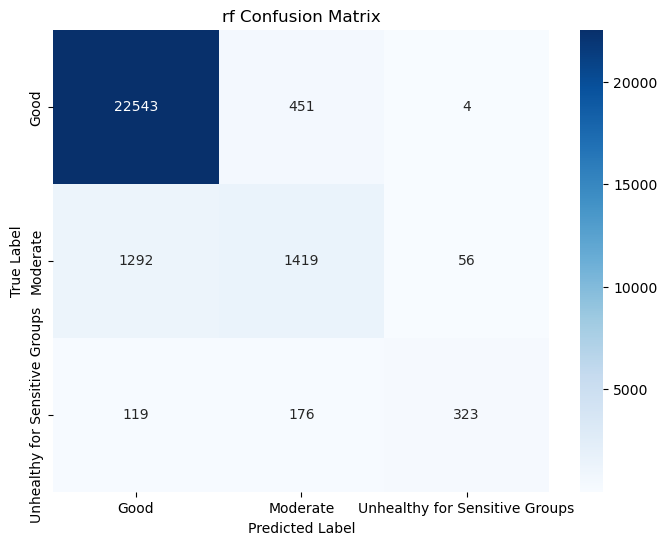

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Convert y_test from one-hot encoding to integer labels
y_test_labels = y_test

# 2. Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_rf)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('rf Confusion Matrix')
plt.show()